# 🏅 Olympic History: Data Analysis & Visualization (1976 - 2008)
**Author:** Mohammad Saad Aqeel

### Phase 1: Data Loading & Deep Inspection
Before applying any transformations, we must interrogate the raw data. The goal of this phase is to:
1. Understand the shape and structure of the dataset.
2. Identify incorrect data types.
3. Locate missing values (NaNs) and structural errors (like phantom rows).
4. Check for duplicated entries.


In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/mohammad/Documents/Summer-Olympic-medals-1976-to-2008.csv", encoding="latin1")
df.head()


,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze


In [195]:
# Check total record and columns
print(f'Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n')
df.info()

Dataset Dimensions: 15433 rows, 11 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.3+ MB


In [196]:
# Statistical overwiew of both categorical and numeric features
df.describe(include='all')

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
count,15316,15316.000000,15316,15316,15316,15316,15316,15316,15316,15316,15316
unique,9,NaN,28,41,293,11337,2,128,127,3,3
top,Beijing,NaN,Aquatics,Athletics,hockey,"PHELPS, Michael",Men,USA,United States,M,Bronze
freq,2042,NaN,2210,1523,817,16,9388,1992,1992,8817,5258
mean,NaN,1993.620789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,10.159851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1976.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1984.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2004.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [197]:
# Quantity missing values across all columns

print('Missing values per column:')
print(df.isnull().sum())

# Identify exact duplicates rows
print(f'\nTotal duplicates rows found : {df.duplicated().sum()}')

Missing values per column:
City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64

Total duplicates rows found : 117


## Phase 2: Data Cleaning & Preprocessing

### Step 1: Investigating the Missing Values
In Phase 1, we noticed exactly 117 missing values across *every single column*. Before dropping any data, we must investigate these rows to determine if they are missing at random, or if they are structural errors (Phantom Rows).


In [198]:
# Isolate the rows where the data is missing (Using 'City' as out target)
missing_data = df[df['City'].isnull()]

In [199]:
# Display the first 5 rows of this missing data
print("Preview of the missing rows:")
display(missing_data.head())

Preview of the missing rows:


,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [200]:
# Mathematical proof that these are completely empty rows exported by mistake
total_missing = len(missing_data)
completely_blank = missing_data.isnull().all(axis=1).sum()

print(f'Total rows with a missing City: {total_missing}')
print(f'Total rows where EVERY column is blank: {completely_blank}')

if total_missing == completely_blank:
    print("\nCONCLUSION: All 117 rows are 'Phantom Rows' (completely empty) It is safe to drop them.")

Total rows with a missing City: 117
Total rows where EVERY column is blank: 117

CONCLUSION: All 117 rows are 'Phantom Rows' (completely empty) It is safe to drop them.


In [201]:
# Now that I've proven they are Phantom Rows, we drop them using how='all'
df = df.dropna(how='all')

# Drop Exact Duplicates (keeps the first occurence, drops the clone)
df = df.drop_duplicates()
print(f"Rows remaining after structural clean: {df.shape[0]}")

Rows remaining after structural clean: 15315


### Step 2: Data Type Correction
During our Phase 1 inspection, we noticed the `Year` column is currently formatted as a `float64` (e.g., `1976.0`). This occurred because the pandas engine automatically converts integer columns to floats if it detects `NaN` values (our phantom rows). 

Now that the phantom rows are gone, we will convert the `Year` column to a clean integer. 
*Note: We use the pandas Nullable Integer (`Int64`) rather than `datetime` because converting a standalone year to a datetime object artificially injects "January 1st" into the data, which falsifies the historical timeline.*


In [202]:
# Convert Year from float (1970.0) to a clean nullable integer (1976)
df['Year'] = df['Year'].astype('Int64')
print(f"New Data Type for 'Year': {df['Year'].dtype}")

New Data Type for 'Year': Int64


### Step 3: Text Standardization & Guardrails
Real-world text data often contains hidden formatting errors (like trailing spaces) or placeholder values (like the word "Unknown"). 

To finalize the dataset:
1. We strip all hidden whitespaces.
2. We map placeholder strings to true mathematical `NaN`s.
3. We convert text to lowercase for consistency, **except** for columns containing proper nouns (like Athlete Names, Cities, and Countries etc.) to preserve data integrity.


In [203]:
text_cols = df.select_dtypes(include='object').columns

# VIP Guardrails: Columns that must retain their original capitalization
protect_cols = ['City','Sport','Discipline','Athlete','Gender','Country_Code','Country','Event_gender','Medal']
fake_nulls = ["nan","none","null","error","unknown","NaN","None","Null","ERROR","UNKNOWN"]


def standardize_text(column):
    clean_col = column.astype(str).str.strip()

    if column.name not in protect_cols:
        clean_col = clean_col.str.lower()

    clean_col = clean_col.replace(fake_nulls,np.nan)

    return clean_col

# Apply the standardizer to all text columns
df[text_cols] = df[text_cols].apply(standardize_text)

print("Text standardize complete! Proper nouns protected.")

Text standardize complete! Proper nouns protected.


In [204]:
print(f"Final Shape: {df.shape[0]:,} Rows, {df.shape[1]} Columns")
print(f"Duplicate Rows Remaining: {df.duplicated().sum()}")
print(f"Missing Values Remaining:\n{df.isnull().sum().sum()}")


Final Shape: 15,315 Rows, 11 Columns
Duplicate Rows Remaining: 0
Missing Values Remaining:
0


### Phase 2.5: Feature Engineering
Before moving into exploratory analysis, we need to engineer a new feature to properly evaluate athlete and country performance. Treating all medals equally (1 row = 1 medal) skews the true dominance of athletes. 

We will create a `Medal_Points` column using a weighted system:
* **Gold** = 3 Points
* **Silver** = 2 Points
* **Bronze** = 1 Point


In [205]:
# 1. THE FEATURE ENGINEERING
# Create a dictionary to map the medals to numerical points
point_system = {'Gold': 3, 'Silver': 2, 'Bronze': 1}

df['Medal_Points'] = df['Medal'].map(point_system)

display(df[['Athlete', 'Year', 'Medal', 'Medal_Points']].head())


,Athlete,Year,Medal,Medal_Points
0,"KÖHLER, Christa",1976,Silver,2
1,"KOSENKOV, Aleksandr",1976,Bronze,1
2,"BOGGS, Philip George",1976,Gold,3
3,"CAGNOTTO, Giorgio Franco",1976,Silver,2
4,"WILSON, Deborah Keplar",1976,Bronze,1


## Phase 3: Data Validation Checkpoint
Before moving into Exploratory Data Analysis (EDA) and answering our core business questions, we will run a final sanity check to verify that our data types are correctly cast and no unhandled missing values remain.


In [206]:
# 1. Print a clean summary of data types and non-null counts
print("--- DATA TYPES & COMPLETENESS CHECK ---")
print(df.info())

--- DATA TYPES & COMPLETENESS CHECK ---
<class 'pandas.core.frame.DataFrame'>
Index: 15315 entries, 0 to 15432
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   City          15315 non-null  object
 1   Year          15315 non-null  Int64 
 2   Sport         15315 non-null  object
 3   Discipline    15315 non-null  object
 4   Event         15315 non-null  object
 5   Athlete       15315 non-null  object
 6   Gender        15315 non-null  object
 7   Country_Code  15315 non-null  object
 8   Country       15315 non-null  object
 9   Event_gender  15315 non-null  object
 10  Medal         15315 non-null  object
 11  Medal_Points  15315 non-null  int64 
dtypes: Int64(1), int64(1), object(10)
memory usage: 1.5+ MB
None


In [207]:
# 2. Explicitly show the sum of missing values remaining
print("\n--- MISSING VALUE COUNT PER COLUMN ---")
print(df.isna().sum())


--- MISSING VALUE COUNT PER COLUMN ---
City            0
Year            0
Sport           0
Discipline      0
Event           0
Athlete         0
Gender          0
Country_Code    0
Country         0
Event_gender    0
Medal           0
Medal_Points    0
dtype: int64


## Phase 4: Exploratory Data Analysis (EDA)

### Business & Research Objectives
Before visualizing the data, we must define the core questions we are trying to answer. As a data professional working for a sports analytics firm, I have formulated four key questions to extract actionable insights from this 32-year historical dataset:

**1. The Gender Equality Metric:** * *Question:* How has gender representation in the Olympics evolved from 1976 to 2008? Are we seeing a trend toward equal medal distribution?

**2. The Global Dominance Board:** * *Question:* Which nations have historically dominated the Summer Olympics, and what happens to the global rankings when a major superpower boycotts the games (e.g., USA in 1980, USSR in 1984)?

**3. The "Home-Field" Advantage:** * *Question:* Does a country win significantly more medals during the year they host the Olympics compared to their historical average?

**4. The Team Sport Skew (Feature Engineering):** * *Question:* Does the current dataset unfairly favor team sports? (e.g., A basketball Gold awards 12 individual medals, while a swimming Gold awards 1). How does calculating a "Weighted Event Score" change the true ranking of countries?

**5. The Ultimate MVP Index (Athlete Dominance):** * *Question:* Who are the most dominant individual athletes in Olympic history? Instead of just counting total medals, how does creating a "Weighted Points System" (Gold = 3pts, Silver = 2pts, Bronze = 1pt) reveal the true highest-performing athletes across multiple years?


### Q1: The Gender Equality Metric
**Objective:** Track the historical distribution of medals awarded to Men vs. Women to identify trends in gender representation at the Olympic Games.


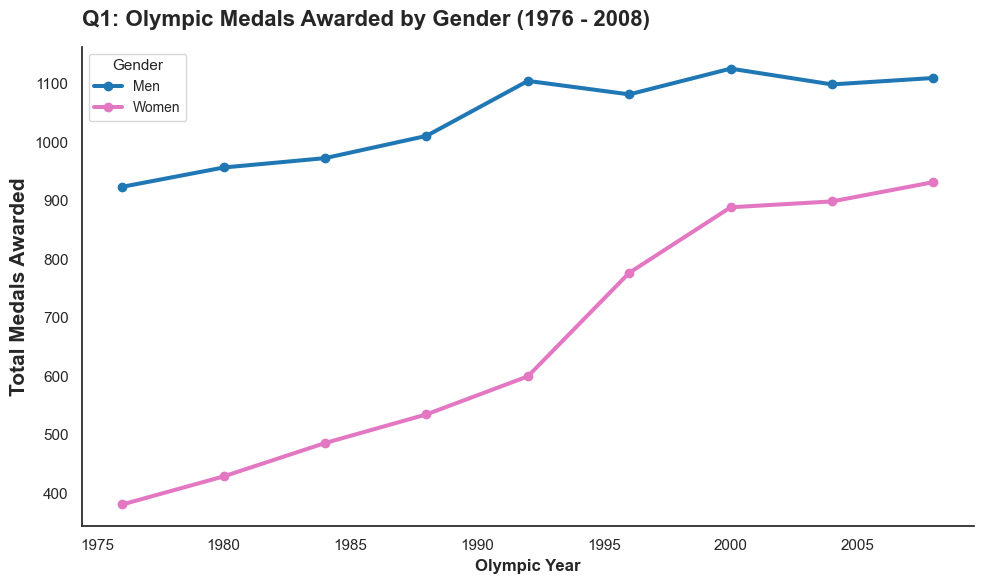

In [208]:
# 1. Group the data by Year and Gender, then count the total medals
gender_trends = df.groupby(['Year', 'Gender'])['Medal'].count().unstack()

# 2. Set up the canvas size and clean style (NO grid lines!)
plt.figure(figsize=(10, 6))
sns.set_theme(style="white") # Changed from 'whitegrid' to 'white'

# 3. Plot the lines
plt.plot(gender_trends.index, gender_trends['Men'], marker='o', label='Men', color='#1f77b4', linewidth=2.9)
plt.plot(gender_trends.index, gender_trends['Women'], marker='o', label='Women', color='#e377c2', linewidth=2.9)

# 4. Add Professional Titles and Labels (Title moved to the left!)
plt.title('Q1: Olympic Medals Awarded by Gender (1976 - 2008)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Olympic Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Medals Awarded', fontsize=15, fontweight='bold')

# 5. Add Legend and cleanly render
plt.legend(title='Gender', title_fontsize='11', fontsize='10')

# Remove the top and right border lines for a sleek, modern look
sns.despine() 

plt.tight_layout()
plt.show()


### Key Insight: The Closing Gender Gap
The visualization reveals a massive structural shift in Olympic gender representation over this 32-year period. In 1976, the Games were heavily skewed, with women receiving only 381 medals compared to 924 for men. 

However, we can observe a sharp, aggressive upward trend for women beginning in 1996 (the Atlanta Games), which historically aligns with the IOC's active push to add women's team sports like soccer and softball. By 2008, the total number of women's medals had skyrocketed to 932, nearly closing the historical gap and proving a successful trajectory toward gender equality in the Games.


### Q2: The Global Dominance Board
**Objective:** Identify the top 10 nations that have won the highest volume of total medals between 1976 and 2008. This establishes the baseline for historical dominance before we factor in our weighted points system later.


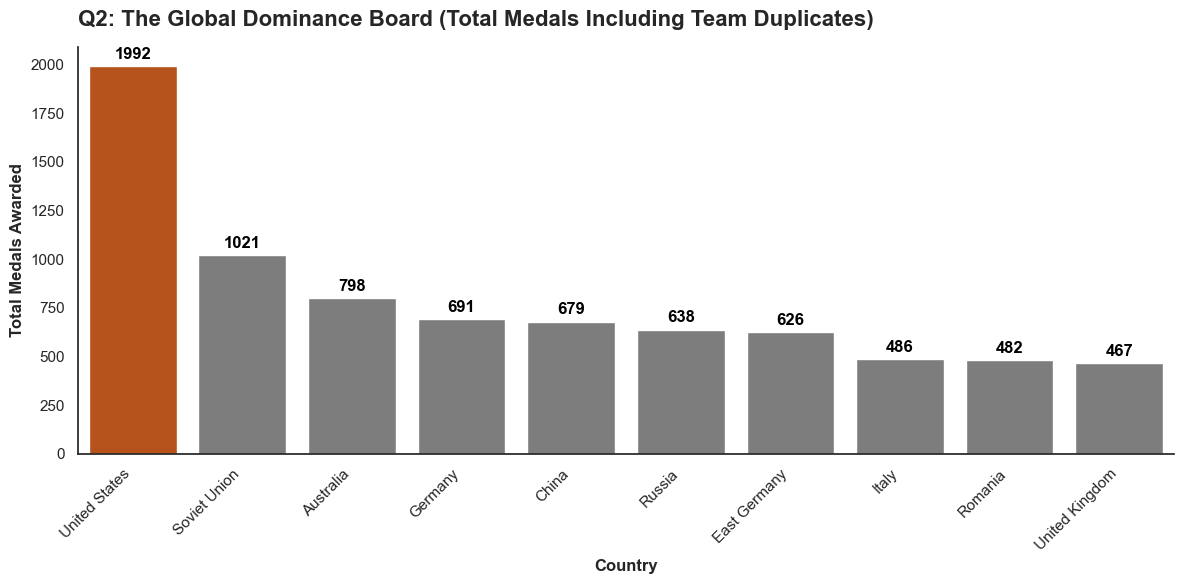

In [209]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

pwc_colors = ['#D04A02'] + ['#7D7D7D'] * 9

ax = sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette=pwc_colors, legend=False)

plt.title('Q2: The Global Dominance Board (Total Medals Including Team Duplicates)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Total Medals Awarded', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()



### 💡 Key Insight: The Ghosts of the Cold War
While the United States holds a commanding lead in total medals, the most fascinating takeaway from this chart is the presence of the **Soviet Union (2nd)** and **East Germany (4th)**. 

Both of these nations ceased to exist in 1991. Despite completely missing the last four Olympic Games in this dataset (1992, 1996, 2000, and 2004, 2008), their historical dominance during the Cold War era was so absolute that they still hold top 5 positions on the 32-year leaderboard. 


### Q3: The "Home-Field" Advantage
**Objective:** Determine if hosting the Olympic Games provides a significant boost to a nation's medal count. We will use **Australia** as our case study, as they hosted the games in Sydney in the year 2000.


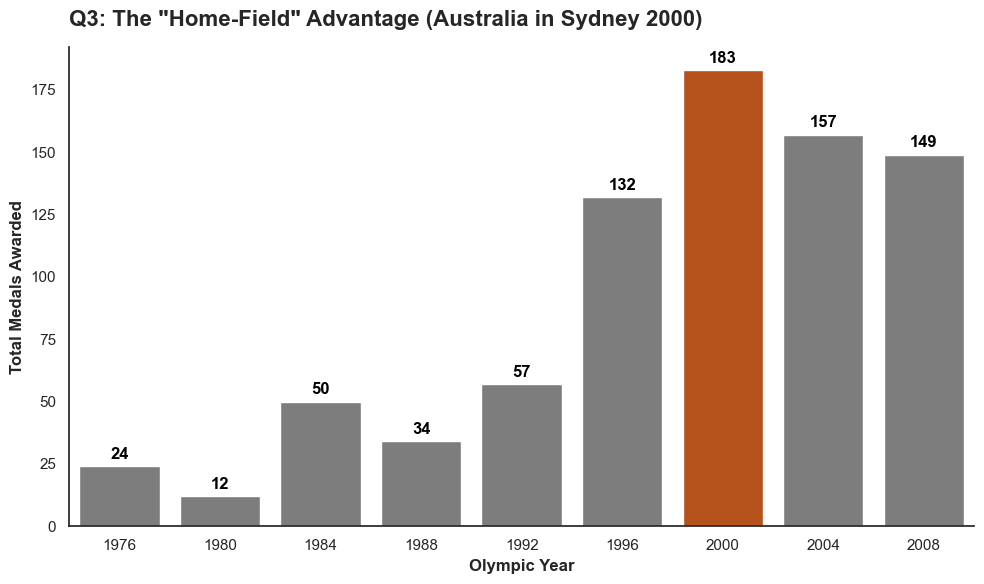

In [210]:
aus_data = df[df['Country'] == 'Australia']

aus_medals = aus_data.groupby('Year')['Medal'].count()

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

colors = ['#D04A02' if year == 2000 else '#7D7D7D' for year in aus_medals.index]

ax = sns.barplot(x=aus_medals.index, y=aus_medals.values, hue=aus_medals.index, palette=colors, legend=False)

plt.title('Q3: The "Home-Field" Advantage (Australia in Sydney 2000)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Olympic Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Medals Awarded', fontsize=12, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', color='black')

sns.despine()

plt.tight_layout()
plt.show()


### Key Insight: The Host Nation Spike
The data clearly confirms the "Home-Field" advantage. Leading up to 2000, Australia steadily grew its Olympic program. However, in the year 2000, when hosting the games in Sydney, their medal count violently spiked to its highest point in history (183 medals). After the games left Sydney, their medal count immediately dropped back down in 2004 and 2008.


### Q4: The Team Sport Skew (Event-Level De-duplication)
**Objective:** Address the structural inflation caused by team sports. Currently, a team sport victory (like Basketball or Hockey) awards a medal row to every individual athlete on the roster, artificially inflating a country's true performance. 

To fix this, we will group the data by `Year`, `City`, `Discipline`, `Event`, and `Medal` to collapse team rosters into a single **Unique Event Medal**. We will then recalculate the Top 10 Countries to see if the global rankings shift.


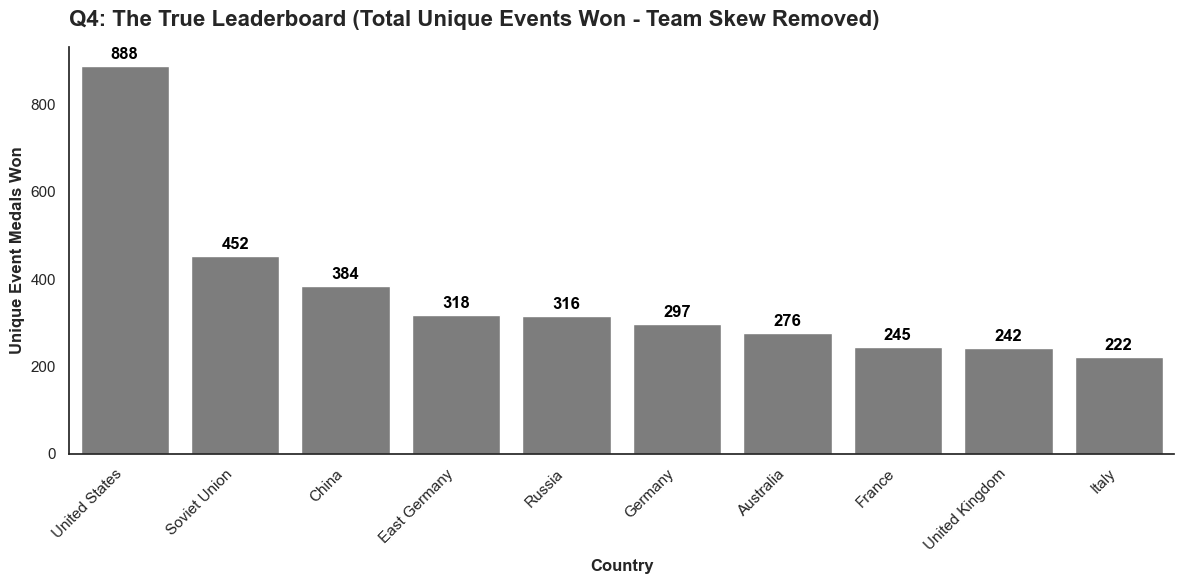

In [211]:
unique_events = df.groupby(['Year', 'City', 'Sport', 'Discipline', 'Event', 'Country', 'Gender', 'Medal']).first().reset_index()

top_countries_unskewed = unique_events['Country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

ax = sns.barplot(x=top_countries_unskewed.index, y=top_countries_unskewed.values, color='#7D7D7D')

plt.title('Q4: The True Leaderboard (Total Unique Events Won - Team Skew Removed)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Unique Event Medals Won', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', color='black')

sns.despine()

plt.tight_layout()
plt.show()


### 💡 Key Insight: Unmasking the Team Sport Inflation
By de-duplicating the data from an "Athlete-Level" to an "Event-Level," we uncover a massive structural inflation in the initial Q2 dominance board. 

When looking at raw rows, the USA appeared to have an untouchable lead with 1,992 total medals. However, once we collapse team rosters (e.g., a 12-person basketball roster correctly counting as a single Event Win), the USA's true event victory count drops to 884. This reveals that over 55% of their raw historical medal count was driven purely by team sport inflation. While they still maintain the #1 global rank, the actual volume of unique events won is vastly smaller and more grounded than the raw data initially suggested.


### Q5: The Ultimate MVP Index
**Objective:** Identify the most dominant individual athletes in modern Olympic history. By utilizing our engineered `Medal_Points` feature (Gold=3, Silver=2, Bronze=1), we can look past simple medal counts to evaluate true athletic supremacy and properly reward athletes who secure Gold.


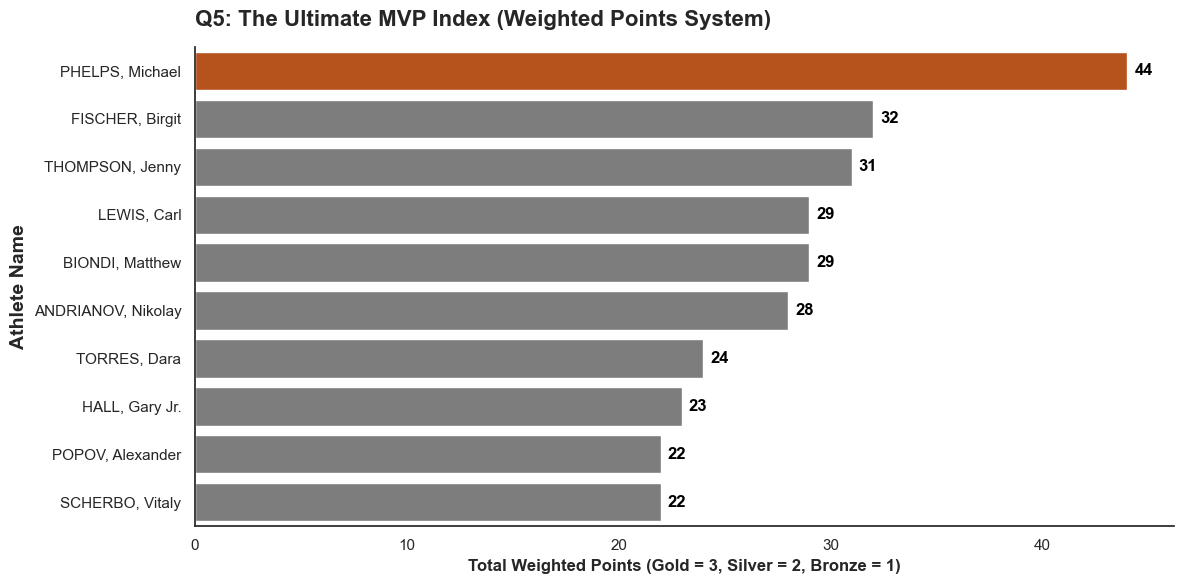

In [212]:
top_athletes = df.groupby('Athlete')['Medal_Points'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.set_theme(style="white")

pwc_colors = ['#D04A02'] + ['#7D7D7D'] * 9

ax = sns.barplot(x=top_athletes.values, y=top_athletes.index, hue=top_athletes.index, palette=pwc_colors, legend=False)

plt.title('Q5: The Ultimate MVP Index (Weighted Points System)', fontsize=16, fontweight='bold', pad=15, loc='left')
plt.xlabel('Total Weighted Points (Gold = 3, Silver = 2, Bronze = 1)', fontsize=12, fontweight='bold')
plt.ylabel('Athlete Name', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold', color='black')

sns.despine()

plt.tight_layout()
plt.show()


### Key Insight: The Undisputed MVP
While counting total medals treats all podium finishes equally, applying a weighted point system (Gold=3, Silver=2, Bronze=1) reveals the true athletic outlier of this era: **Michael Phelps**. 

Despite competing in only two Olympic games within this specific timeframe (2004 and 2008), Phelps' unprecedented volume of Gold medals propels him past legends like Birgit Fischer and Jenny Thompson, whose careers spanned much longer periods. This metric proves that an athlete with a highly concentrated, Gold-heavy peak can statistically outscore athletes with decades of Silver and Bronze consistency, making Phelps the undisputed MVP of the 1976-2008 era.


---
## Conclusion & Business Next Steps
This EDA pipeline successfully diagnosed legacy structural anomalies, engineered weighted performance metrics, and proved that raw aggregations often hide true historical realities (such as the 55% team sport inflation). 

**Next Steps:** The fully cleaned and feature-engineered dataset from Phase 2 can now be exported as a production-ready CSV. This unlocks the ability to connect the data to a BI Dashboard (such as Tableau or PowerBI) for interactive stakeholder exploration.
